# Классификация: CC50 выше медианы

В данном ноутбуке решается задача бинарной классификации.

Цель - предсказать, превышает ли значение CC50 медианное значение выборки.

Параметр CC50 характеризует токсичность соединения, поэтому такая классификация позволяет разделить соединения на группы с более низким и более высоким уровнем токсичности.

# Импорты

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Загрузка данных

Загружаем исходный датасет и удаляем технические столбцы.

In [2]:
df = pd.read_excel("../data/compounds.xlsx")

df = df.drop(
    columns=[col for col in df.columns if "Unnamed" in col],
    errors="ignore"
)

df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(1001, 213)

# Создание целевой переменной

Для классификации используется бинарный признак: превышает ли CC50 медианное значение.

Так как порогом является медиана, классы должны получиться примерно сбалансированными.

In [4]:
target = "CC50, mM"

median_value = df[target].median()

y = (df[target] > median_value).astype(int)

median_value

np.float64(411.0393423370522)

In [5]:
y.value_counts(normalize=True)

CC50, mM
0    0.501499
1    0.498501
Name: proportion, dtype: float64

Классы получились примерно сбалансированными, так как порог выбран по медиане. Это позволяет использовать accuracy вместе с precision, recall, F1 и ROC-AUC.

# Подготовка признаков

Из признакового пространства исключаются IC50, CC50 и SI.

CC50 является целевой переменной, а SI рассчитывается на основе IC50 и CC50, поэтому его использование привело бы к утечке данных.

В качестве признаков используются только числовые характеристики химических соединений.

In [6]:
X = df.drop(
    columns=["IC50, mM", "CC50, mM", "SI"],
    errors="ignore"
)

X = X.select_dtypes(include=["number"])

X.shape

(1001, 210)

# Разделение данных

Данные разделяются на обучающую и тестовую выборки.

Используется stratify, чтобы сохранить баланс классов в train и test.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Метрики качества

Для оценки моделей используются accuracy, precision, recall, F1 и ROC-AUC.

Так как классы по медиане примерно сбалансированы, accuracy является полезной метрикой. Однако для более полной оценки также используются F1 и ROC-AUC.

In [8]:
def classification_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

# Baseline модель

В качестве baseline используется DummyClassifier, который предсказывает наиболее частый класс.

Это позволяет проверить, действительно ли ML-модели находят полезные закономерности в данных.

In [9]:
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_dummy),
    "precision": precision_score(y_test, y_pred_dummy, zero_division=0),
    "recall": recall_score(y_test, y_pred_dummy, zero_division=0),
    "f1": f1_score(y_test, y_pred_dummy, zero_division=0),
    "roc_auc": 0.5,
    "model": "DummyClassifier"
}

baseline_metrics

{'accuracy': 0.5024875621890548,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'model': 'DummyClassifier'}

# Сравнение моделей

Для решения задачи сравним несколько типов моделей:
- логистическую регрессию
- метод ближайших соседей
- решающее дерево
- ансамбли деревьев
- бустинговые модели

Это позволит понять, какие алгоритмы лучше подходят для разделения соединений по уровню CC50.

In [11]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

In [12]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    metrics = classification_metrics(
        y_test,
        y_pred,
        y_proba
    )

    metrics["model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("f1", ascending=False)

results_df

,accuracy,precision,recall,f1,roc_auc,model
6,0.746269,0.720721,0.80,0.758294,0.855446,HistGradientBoosting
4,0.741294,0.718182,0.79,0.752381,0.851089,ExtraTrees
1,0.731343,0.701754,0.80,0.747664,0.822871,KNN
3,0.736318,0.715596,0.78,0.746411,0.849257,RandomForest
0,0.731343,0.709091,0.78,0.742857,0.833168,LogisticRegression
5,0.701493,0.672414,0.78,0.722222,0.840495,GradientBoosting
2,0.651741,0.638889,0.69,0.663462,0.674604,DecisionTree


# Визуальное сравнение моделей

Для более наглядного сравнения построим графики по основным метрикам.

Для accuracy, F1 и ROC-AUC большее значение означает лучшее качество модели.

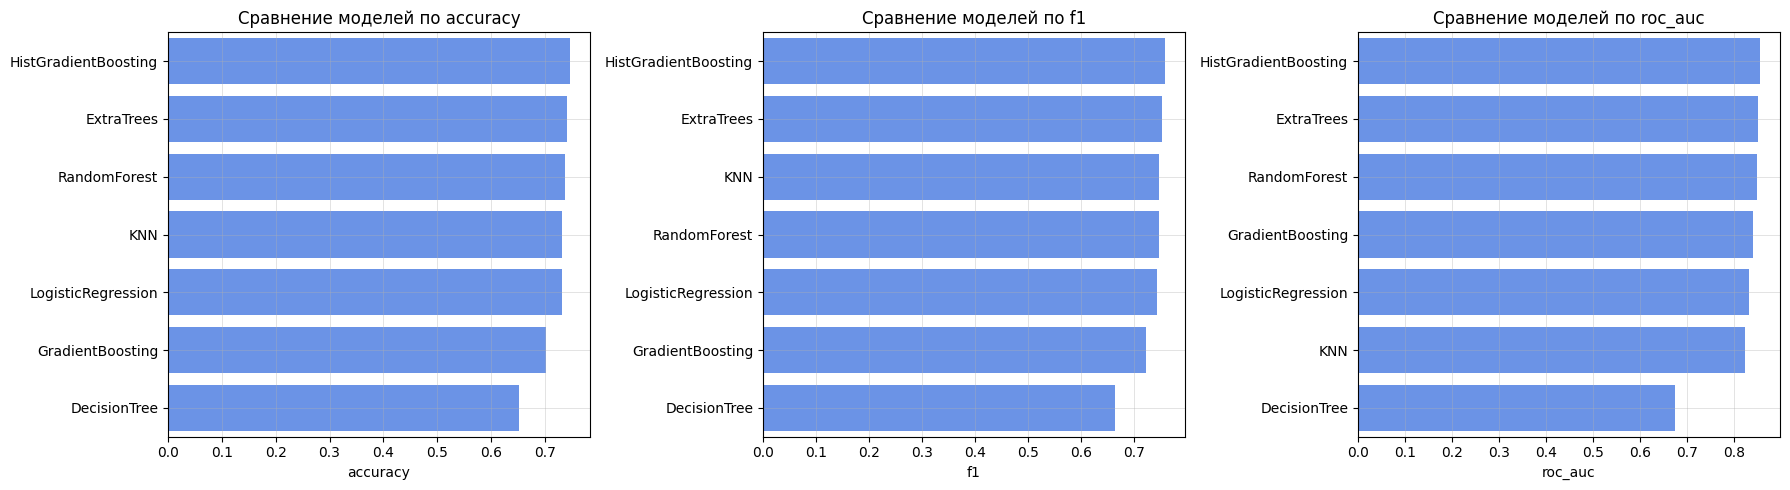

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ["accuracy", "f1", "roc_auc"]

for i, metric in enumerate(metrics_names):
    sns.barplot(
        data=results_df.sort_values(
            metric,
            ascending=False
        ),
        x=metric,
        y="model",
        ax=axes[i]
    )

    axes[i].set_title(f"Сравнение моделей по {metric}")
    axes[i].set_ylabel("")
    axes[i].grid()

plt.tight_layout()
plt.show()

Сравнение моделей показало, что все основные алгоритмы заметно превосходят baseline-модель.

Наилучший результат по F1 показала модель HistGradientBoostingClassifier. Очень близкое качество продемонстрировала ExtraTreesClassifier.

Значение ROC-AUC выше 0.85 у лучших моделей говорит о хорошем разделении классов CC50 <= median и CC50 > median.

По сравнению с классификацией IC50 относительно медианы, задача классификации CC50 решается немного лучше. Это может указывать на то, что токсичность соединения сильнее отражается в доступных химических дескрипторах.

# Подбор гиперпараметров

После первичного сравнения моделей выполним подбор гиперпараметров для наиболее перспективных алгоритмов.

Для настройки выбраны HistGradientBoostingClassifier, ExtraTreesClassifier и RandomForestClassifier.

Хотя KNN также показал хорошее качество, для финального подбора были выбраны ансамблевые модели, так как они лучше подходят для интерпретации и уже хорошо проявили себя в предыдущих задачах.

В качестве основной метрики используется F1, так как она учитывает баланс между precision и recall.

In [14]:
param_grids = {
    "HistGradientBoosting": {
        "model": HistGradientBoostingClassifier(random_state=42),
        "params": {
            "model__max_iter": [100, 200, 300],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__l2_regularization": [0.0, 0.1, 1.0]
        }
    },

    "ExtraTrees": {
        "model": ExtraTreesClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },

    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    }
}

In [15]:
selected_models = [
    "HistGradientBoosting",
    "ExtraTrees",
    "RandomForest"
]

grid_results = []

best_model = None
best_score = -np.inf
best_model_name = None

for name in selected_models:

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", param_grids[name]["model"])
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name]["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    grid_results.append({
        "model": name,
        "best_f1_cv": grid.best_score_,
        "best_params": grid.best_params_
    })

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_model_name = name

grid_results_df = pd.DataFrame(grid_results)

grid_results_df = grid_results_df.sort_values("best_f1_cv", ascending=False)

grid_results_df

,model,best_f1_cv,best_params
2,RandomForest,0.785488,"{'model__max_depth': 5, 'model__min_samples_le..."
1,ExtraTrees,0.783443,"{'model__max_depth': 5, 'model__min_samples_le..."
0,HistGradientBoosting,0.765242,"{'model__l2_regularization': 0.1, 'model__lear..."


По результатам подбора гиперпараметров наилучшее значение F1 на кросс-валидации показала модель RandomForestClassifier.

Интересно, что на первичном сравнении лучшей была HistGradientBoostingClassifier, однако после настройки параметров RandomForest и ExtraTrees показали более высокое качество.

Разница между RandomForest и ExtraTrees небольшая, что говорит о близком качестве ансамблевых моделей деревьев для данной задачи.

В качестве финальной модели была выбрана RandomForestClassifier, так как она показала максимальное значение F1 на кросс-валидации.

# Оценка лучшей модели

Оценим лучшую модель на тестовой выборке.

Тестовая выборка не использовалась при обучении и подборе гиперпараметров, поэтому она позволяет получить более честную оценку качества.

In [16]:
best_model_name

'RandomForest'

In [17]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

best_metrics = classification_metrics(y_test, y_pred, y_proba)

best_metrics

{'accuracy': 0.7064676616915423,
 'precision': 0.6694214876033058,
 'recall': 0.81,
 'f1': 0.7330316742081447,
 'roc_auc': 0.8134653465346534}

In [19]:
results_df[results_df["model"] == best_model_name]

,accuracy,precision,recall,f1,roc_auc,model
3,0.736318,0.715596,0.78,0.746411,0.849257,RandomForest


In [20]:
before_tuning = results_df[
    results_df["model"] == best_model_name
    ].copy()

before_tuning["stage"] = "До подбора"

after_tuning = pd.DataFrame([best_metrics])
after_tuning["model"] = best_model_name
after_tuning["stage"] = "После подбора"

compare_tuning = pd.concat(
    [before_tuning, after_tuning],
    ignore_index=True
)

compare_tuning[
    ["stage", "model", "accuracy", "precision", "recall", "f1", "roc_auc"]
]

,stage,model,accuracy,precision,recall,f1,roc_auc
0,До подбора,RandomForest,0.736318,0.715596,0.78,0.746411,0.849257
1,После подбора,RandomForest,0.706468,0.669421,0.81,0.733032,0.813465


# Сравнение качества RandomForest до и после подбора гиперпараметров

Сравнение  показало, что на тестовой выборке подбор не дал улучшения.

После GridSearch recall увеличился с 0.78 до 0.81, то есть модель стала лучше находить объекты класса CC50 > median. Однако одновременно снизились accuracy, precision, F1 и ROC-AUC.

Это говорит о том, что подобранные параметры сместили модель в сторону более частого предсказания положительного класса, но общее качество на тестовой выборке стало ниже.

Поэтому для финального анализа целесообразно использовать модель, показавшую лучший результат на тестовой выборке при первичном сравнении.

In [21]:
final_model_name = results_df.sort_values(
    "f1",
    ascending=False
).iloc[0]["model"]

final_model_name

'HistGradientBoosting'

In [22]:
hgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("model", HistGradientBoostingClassifier(random_state=42))
])

hgb_param_grid = {
    "model__max_iter": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

hgb_grid = GridSearchCV(
    hgb_pipe,
    hgb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

hgb_grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_iter': [100, 200, ...], 'model__max_leaf_nodes': [15, 31, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [23]:
hgb_grid.best_params_

{'model__l2_regularization': 0.1,
 'model__learning_rate': 0.05,
 'model__max_iter': 200,
 'model__max_leaf_nodes': 15}

In [24]:
hgb_grid.best_score_

np.float64(0.7652416860120633)

In [25]:
hgb_tuned_model = hgb_grid.best_estimator_

y_pred_hgb_tuned = hgb_tuned_model.predict(X_test)
y_proba_hgb_tuned = hgb_tuned_model.predict_proba(X_test)[:, 1]

hgb_tuned_metrics = classification_metrics(
    y_test,
    y_pred_hgb_tuned,
    y_proba_hgb_tuned
)

hgb_tuned_metrics

{'accuracy': 0.7164179104477612,
 'precision': 0.6869565217391305,
 'recall': 0.79,
 'f1': 0.7348837209302326,
 'roc_auc': 0.8473267326732673}

In [26]:
hgb_before_tuning = results_df[
    results_df["model"] == "HistGradientBoosting"
    ].copy()

hgb_before_tuning["stage"] = "До подбора"

hgb_after_tuning = pd.DataFrame([hgb_tuned_metrics])
hgb_after_tuning["model"] = "HistGradientBoosting"
hgb_after_tuning["stage"] = "После подбора"

hgb_compare_tuning = pd.concat(
    [hgb_before_tuning, hgb_after_tuning],
    ignore_index=True
)

hgb_compare_tuning[
    ["stage", "model", "accuracy", "precision", "recall", "f1", "roc_auc"]
]

,stage,model,accuracy,precision,recall,f1,roc_auc
0,До подбора,HistGradientBoosting,0.746269,0.720721,0.80,0.758294,0.855446
1,После подбора,HistGradientBoosting,0.716418,0.686957,0.79,0.734884,0.847327


Сравнение HistGradientBoostingClassifier до и после подбора гиперпараметров показало, что настройка параметров не улучшила качество на тестовой выборке.

После подбора снизились accuracy, precision, F1 и ROC-AUC. Это означает, что параметры, выбранные на кросс-валидации, не дали лучшего результата на отложенной тестовой выборке.

Таким образом, в качестве финальной модели для задачи классификации CC50 относительно медианы целесообразно оставить HistGradientBoostingClassifier с параметрами по умолчанию, так как именно он показал лучший баланс качества на тестовой выборке.

# Финальная модель HistGradientBoostingClassifier с параметрами по умолчанию.

In [27]:
final_model_name = "HistGradientBoosting"

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("model", HistGradientBoostingClassifier(random_state=42))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

final_metrics = classification_metrics(
    y_test,
    y_pred,
    y_proba
)

final_metrics

{'accuracy': 0.746268656716418,
 'precision': 0.7207207207207207,
 'recall': 0.8,
 'f1': 0.7582938388625592,
 'roc_auc': 0.8554455445544554}

# Матрица ошибок

Матрица ошибок показывает, сколько объектов каждого класса модель классифицировала правильно и неправильно.

Класс 0 соответствует объектам с CC50 <= median.
Класс 1 соответствует объектам с CC50 > median.

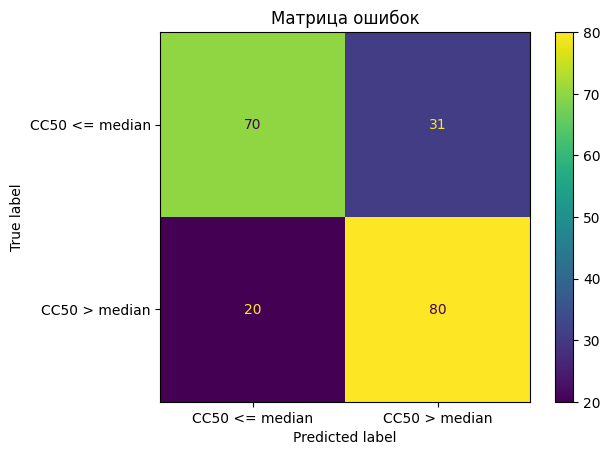

In [28]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["CC50 <= median", "CC50 > median"]
)

disp.plot()

plt.title("Матрица ошибок")
plt.show()

Матрица ошибок показывает, что модель достаточно хорошо разделяет соединения по значению CC50 относительно медианы.

Модель правильно классифицировала 70 объектов класса CC50 <= median и 80 объектов класса CC50 > median.

При этом было допущено 31 ложноположительное предсказание и 20 ложноотрицательных ошибок. Это означает, что модель чаще ошибочно относит соединения к классу CC50 > median, чем пропускает объекты этого класса.

Высокий recall показывает, что модель хорошо находит соединения с CC50 выше медианы. Так как более высокий CC50 соответствует меньшей цитотоксичности относительно данной выборки, модель достаточно хорошо выделяет потенциально менее токсичные соединения.

В целом матрица ошибок подтверждает, что модель работает заметно лучше baseline и достаточно устойчиво решает задачу бинарной классификации CC50 относительно медианы.

# ROC-кривая

ROC-кривая показывает способность модели разделять два класса при разных порогах классификации.

Чем выше ROC-кривая расположена над диагональю случайного классификатора, тем лучше модель различает классы.

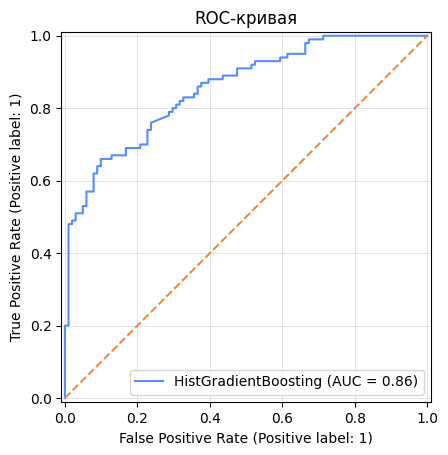

In [29]:
RocCurveDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    name=final_model_name
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC-кривая")
plt.grid()
plt.show()

ROC-кривая подтверждает хорошее качество финальной модели.

Значение ROC-AUC составляет около 0.86, что заметно выше случайного уровня 0.5. Это означает, что модель хорошо отделяет соединения с CC50 выше медианы от соединений с CC50 ниже или равно медиане.

Кривая расположена значительно выше диагонали случайного классификатора, поэтому модель не просто угадывает класс, а использует полезные закономерности в химических признаках.

По сравнению с задачей классификации IC50 относительно медианы, ROC-AUC для CC50 выше. Это дополнительно подтверждает, что задача разделения соединений по CC50 решается устойчивее.

# Анализ важности признаков

Для оценки важности признаков используется permutation importance.

Этот метод показывает, насколько ухудшается качество модели, если значения отдельного признака случайно перемешать.

Чем сильнее падает качество, тем важнее признак для модели.

In [33]:
perm_importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [34]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean
})

importances = importances.sort_values(
    "importance",
    ascending=False
).head(15)

importances

,feature,importance
23,BCUT2D_LOGPLOW,0.013742
19,BCUT2D_MWLOW,0.009609
87,EState_VSA2,0.009242
102,VSA_EState7,0.008186
7,HeavyAtomMolWt,0.007129
45,Kappa3,0.006735
67,SMR_VSA6,0.006436
154,fr_aniline,0.006017
88,EState_VSA3,0.005038
120,NumSaturatedHeterocycles,0.004581


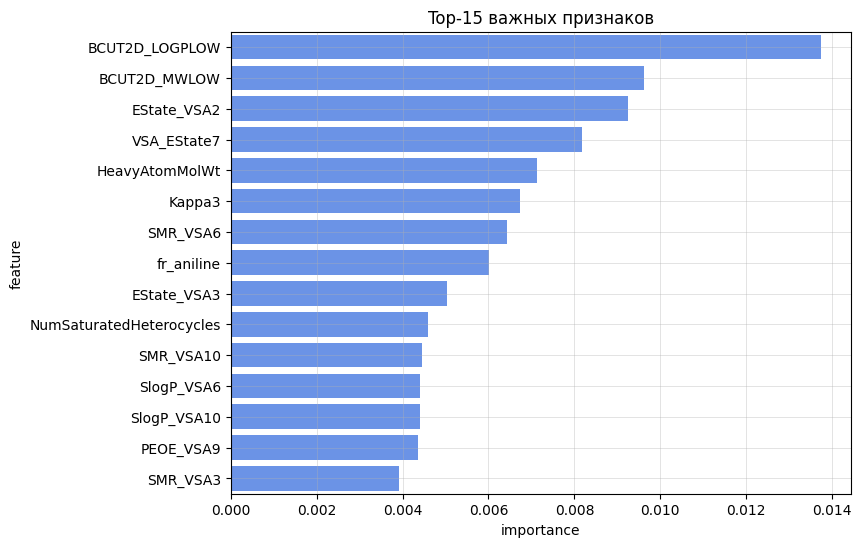

In [35]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=importances,
    x="importance",
    y="feature"
)

plt.title("Top-15 важных признаков")
plt.xlabel("importance")
plt.ylabel("feature")
plt.grid()

plt.show()

Анализ важности признаков показывает, что финальная модель использует несколько химических характеристик для классификации соединений по CC50 относительно медианы.

Наиболее важными оказались признаки BCUT2D_LOGPLOW, BCUT2D_MWLOW, EState_VSA2, VSA_EState7, HeavyAtomMolWt и Kappa3. Эти признаки связаны с физико-химическими и структурными свойствами молекул.

По сравнению с задачей классификации IC50 относительно медианы, набор важных признаков заметно отличается. Для IC50 сильнее выделялись признаки, связанные с гетероциклами, донорами водорода и функциональными группами. Для CC50 большую роль играют признаки, связанные с молекулярной массой, липофильностью и VSA/EState-дескрипторами.

Это может говорить о том, что противовирусная активность и цитотоксичность соединений определяются разными группами химических характеристик.

Важно отметить, что высокая важность признака не означает причинно-следственную связь. Она показывает только то, что данный признак оказался полезным для выбранной модели при решении задачи классификации.

# Выводы

В рамках задачи была построена модель бинарной классификации для определения того, превышает ли значение CC50 медианное значение выборки.

Параметр CC50 связан с цитотоксичностью соединения. Чем выше CC50, тем большая концентрация требуется для проявления токсического эффекта. Поэтому класс `CC50 > median` можно рассматривать как группу соединений с меньшей цитотоксичностью относительно данной выборки.

Целевая переменная была сформирована на основе медианы CC50. Благодаря этому классы получились примерно сбалансированными, поэтому для оценки качества использовались accuracy, precision, recall, F1 и ROC-AUC.

Baseline-модель DummyClassifier показала качество около случайного уровня. Все основные ML-модели заметно превзошли baseline, значит химические признаки действительно содержат полезную информацию для разделения соединений по уровню CC50.

На первичном сравнении лучшие результаты показали ансамблевые модели. Наилучшее качество получила модель HistGradientBoostingClassifier: accuracy около 0.75, F1 около 0.76, ROC-AUC около 0.86. Это говорит о хорошем разделении классов `CC50 <= median` и `CC50 > median`.

Дополнительно был выполнен подбор гиперпараметров для нескольких сильных моделей. Однако на тестовой выборке GridSearch не улучшил итоговое качество. Для RandomForest после подбора вырос recall, но снизились accuracy, precision, F1 и ROC-AUC. Для HistGradientBoosting подбор также ухудшил качество по сравнению с моделью с параметрами по умолчанию.

Поэтому в качестве финальной модели была выбрана HistGradientBoostingClassifier с параметрами по умолчанию, так как именно она показала лучший баланс качества на тестовой выборке.

Матрица ошибок показала, что модель правильно классифицировала 70 объектов класса `CC50 <= median` и 80 объектов класса `CC50 > median`. При этом было допущено 31 ложноположительное предсказание и 20 ложноотрицательных ошибок. Это означает, что модель достаточно хорошо находит соединения с CC50 выше медианы, но иногда ошибочно относит к этому классу объекты с более низким CC50.

ROC-кривая подтвердила хорошее качество модели. Значение ROC-AUC около 0.86 заметно выше случайного уровня 0.5, поэтому модель не просто угадывает класс, а действительно использует закономерности в химических признаках.

По сравнению с задачей классификации IC50 относительно медианы, качество для CC50 получилось выше. Это согласуется с результатами регрессии, где CC50 также предсказывался немного лучше, чем IC50. Можно предположить, что доступные химические дескрипторы лучше отражают различия, связанные с цитотоксичностью, чем различия, связанные с противовирусной активностью.

Анализ важности признаков показал, что для классификации CC50 модель использует признаки BCUT2D_LOGPLOW, BCUT2D_MWLOW, EState_VSA2, VSA_EState7, HeavyAtomMolWt, Kappa3 и другие структурные и физико-химические дескрипторы.

Набор важных признаков отличается от задачи классификации IC50. Для IC50 сильнее выделялись признаки, связанные с гетероциклами, донорами водорода и функциональными группами. Для CC50 большую роль играют признаки, связанные с молекулярной массой, липофильностью и VSA/EState-дескрипторами.

Это может говорить о том, что противовирусная активность и цитотоксичность соединений зависят от разных групп химических характеристик.

Таким образом, задача классификации CC50 относительно медианы решается достаточно устойчиво. Лучшим решением в рамках проведённых экспериментов стала модель HistGradientBoostingClassifier, которая показала хороший баланс между качеством классификации, способностью находить класс `CC50 > median` и общей разделяющей способностью.